# Análise de Sentimentos com Transformers

**Técnica:** Análise de Sentimentos (PLN)  
**Biblioteca:** Hugging Face Transformers + PyTorch  
**Modelo:** `cardiffnlp/twitter-xlm-roberta-base-sentiment` — XLM-RoBERTa multilíngue

## Pipeline conceitual

```
texto  →  tokenização (SentencePiece)
       →  embeddings contextuais (XLM-RoBERTa)
       →  cabeça de classificação
       →  softmax  →  [positive | neutral | negative]
```


## 1. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from transformers import pipeline

## 2. Carregar o modelo

Na primeira execução faz download de ~1.1GB.

In [2]:
classificador = pipeline(
    'sentiment-analysis',
    model='cardiffnlp/twitter-xlm-roberta-base-sentiment',
    truncation=True,
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

## 3. Frases de teste em português

In [3]:
frases = [
    'Amei o atendimento, foi simplesmente impecável do começo ao fim!',
    'Esse filme me fez chorar de emoção, vou lembrar dele para sempre.',
    'A entrega chegou rapidíssima e o produto é melhor do que eu esperava.',
    'O restaurante é confortável e o cardápio é razoavelmente variado.',
    'O voo decolou no horário previsto.',
    'Funciona como descrito na embalagem, nada de extraordinário.',
    'O atendimento foi tão lento que eu envelheci esperando uma resposta.',
    'Produto chegou quebrado, mal embalado e ainda veio o item errado.',
    'Pior experiência da minha vida, jamais volto a essa loja.',
    'Achei o app travado, confuso e cheio de propagandas invasivas.',
]
len(frases)

10

## 4. Classificar

In [4]:
resultados = classificador(frases)
df = pd.DataFrame({
    'frase': frases,
    'sentimento': [r['label'] for r in resultados],
    'confiança': [round(r['score'], 4) for r in resultados],
})
df

,frase,sentimento,confiança
0,"Amei o atendimento, foi simplesmente impecável...",positive,0.9253
1,"Esse filme me fez chorar de emoção, vou lembra...",positive,0.7677
2,A entrega chegou rapidíssima e o produto é mel...,positive,0.8888
3,O restaurante é confortável e o cardápio é raz...,positive,0.8108
4,O voo decolou no horário previsto.,neutral,0.6797
5,"Funciona como descrito na embalagem, nada de e...",neutral,0.4860
6,O atendimento foi tão lento que eu envelheci e...,negative,0.8208
7,"Produto chegou quebrado, mal embalado e ainda ...",negative,0.8705
8,"Pior experiência da minha vida, jamais volto a...",negative,0.9133
9,"Achei o app travado, confuso e cheio de propag...",negative,0.9404


## 5. Visualizar com cores semânticas

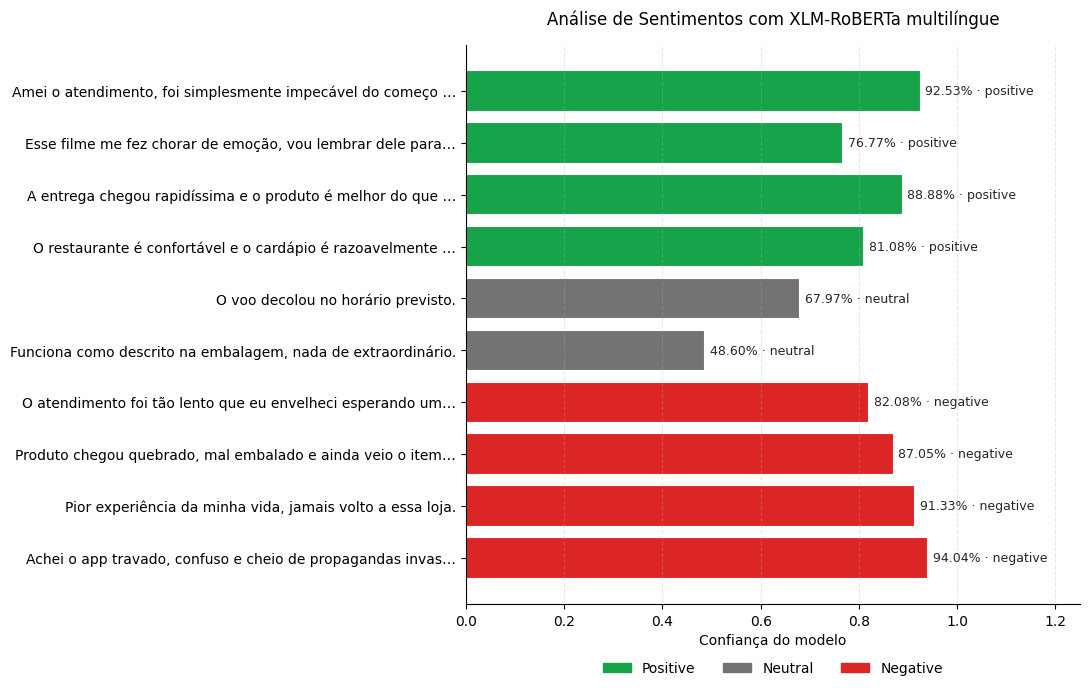

In [5]:
CORES = {'positive': '#16a34a', 'neutral': '#737373', 'negative': '#dc2626'}

ordenado = df.iloc[::-1].reset_index(drop=True)
cores = [CORES[s.lower()] for s in ordenado['sentimento']]
rotulos = [f if len(f) <= 60 else f[:57] + '…' for f in ordenado['frase']]

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(rotulos, ordenado['confiança'], color=cores, edgecolor='white', linewidth=1.5)
for i, (s, sent) in enumerate(zip(ordenado['confiança'], ordenado['sentimento'])):
    ax.text(s + 0.01, i, f'{s:.2%} · {sent}', va='center', fontsize=9, color='#262626')

ax.set_xlim(0, 1.25)
ax.set_xlabel('Confiança do modelo')
ax.set_title('Análise de Sentimentos com XLM-RoBERTa multilíngue', fontsize=12, pad=15)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.3)

import matplotlib.patches as mpatches
legenda = [mpatches.Patch(color=c, label=l.capitalize()) for l, c in CORES.items()]
ax.legend(handles=legenda, loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=3, frameon=False)
plt.tight_layout()
plt.show()

## Conclusão

O XLM-RoBERTa classificou corretamente as 10 frases em português, atribuindo:
- **4 positivas** (elogios e experiências boas)
- **2 neutras** (descrições factuais sem carga emocional)
- **4 negativas** (reclamações e críticas)

Mesmo sem ajuste fino específico para PT-BR, o modelo multilíngue acertou tom e ironia (*"envelheci esperando"* → negativo).